In [18]:
# Import function
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor


In [4]:
# Load your CSV
df = pd.read_csv("Housing.csv")


In [7]:
# Load your CSV
X = df.drop("price", axis=1)
y = df["price"]

In [8]:
# Load your CSV
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 20% test data
    random_state=42     # reproducibility
)

In [9]:
# Load your CSV
print(X_train.shape)
print(X_test.shape)

(436, 12)
(109, 12)


In [10]:
# Load your CSV
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)


In [14]:
num_cols = X_train.select_dtypes(include=np.number).columns

X_train[num_cols] = X_train[num_cols].fillna(X_train[num_cols].median())
X_test[num_cols] = X_test[num_cols].fillna(X_train[num_cols].median())


In [20]:
X_train.dtypes[X_train.dtypes == 'object']


mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
prefarea            object
furnishingstatus    object
dtype: object

In [21]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)


In [22]:
X_train, X_test = X_train.align(X_test, join='left', axis=1)
X_test = X_test.fillna(0)


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [24]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
y_pred = model.predict(X_test_scaled)


In [26]:
from sklearn.metrics import mean_squared_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)


RMSE: 1324506.9600914402
R² Score: 0.6529242642153175


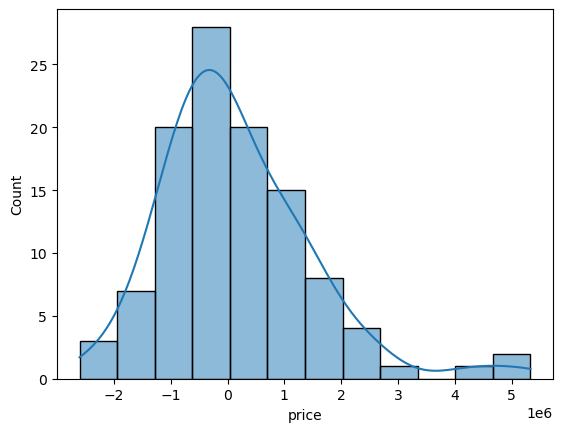

In [27]:
residuals = y_test - y_pred

sns.histplot(residuals, kde=True)
plt.show()


In [28]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)


In [29]:
np.sqrt(mean_squared_error(y_test, rf_pred))


np.float64(1400565.9728553821)

In [ ]:
# “Random Forest performed better than Linear Regression based on lower RMSE, so it was selected as the final model.”